<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
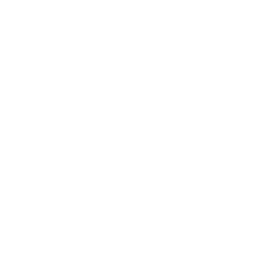
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Vytížení zdrojů nemocničních oddělení — vodorovný sloupcový graf</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Zdravotnictví / Provoz nemocnice &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Souhrn

Tento příklad používá vodorovné sloupcové grafy (HBAR) procedury **PROC GCHART** k profilaci pracovní doby personálu napříč šesti klinickými odděleními za Q1 2026. Syntetický protokol pracovní síly s **90 záznamy směn** (15 na oddělení) pohání tři pohledy: seřazený graf celkových hodin, průměrnou délku směny na oddělení a seskupené HBAR grafy, které rozdělují každé oddělení podle kategorie zdroje a podle směny. `SUMVAR=` sčítá skutečné odpracované hodiny místo počítání záznamů, `TYPE=SUM`/`TYPE=MEAN` přepínají statistiku odezvy, `DESCENDING` řadí oddělení sestupně a `GROUP=` kreslí sousedící seskupené sloupce pro druhý rozměr.

Výstup podporuje čtvrtletní přezkum provozní efektivity: ukazuje, která oddělení spotřebovávají nejvíce práce, která mají nejdelší směny, a jak se vzorec obsazení denní/odpolední/noční směny liší mezi jednotkami s nepřetržitou akutní péčí a denními službami.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Jednotlivé záznamy pracovní doby směn s odpracovanými hodinami | 90 |
| WORK.DEPT_SUMMARY | Souhrny za oddělení a průměrná délka směny | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generování syntetického protokolu pracovní doby
   nemocničního personálu.
   Q1 2026: 6 klinických oddělení, 4 kategorie zdrojů,
   3 směny. Přizpůsobeno na 15 záznamů směn na oddělení
   (90 celkem), aby zůstal viditelný celý seznam oddělení.
   -------------------------------------------------------- */
data work.staffing_log;
    CALL streaminit(20260601);
    DÉLKA department $20 resource_type $30 shift $16;

    /* mix kategorií zdrojů (personál se zaměřením na ošetřovatelství) */
    POLE resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* základní mix směn, nakloněn k noční směně u nepřetržitých provozů */
    POLE shfw[3] _temporary_ (0.45 0.30 0.25);
    POLE nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    OPAKUJ di = 1 TO 6;
        KDYŽ di = 1 PAK department = 'Pohotovost';
        JINAK KDYŽ di = 2 PAK department = 'Chirurgie';
        JINAK KDYŽ di = 3 PAK department = 'JIP';
        JINAK KDYŽ di = 4 PAK department = 'Pediatrie';
        JINAK KDYŽ di = 5 PAK department = 'Onkologie';
        JINAK department = 'Porodnice';

        OPAKUJ rec = 1 TO 15;

            /* typ zdroje pomocí váženého losování */
            u = rand('uniform'); cum = 0;
            OPAKUJ r = 1 TO 4;
                cum + resw[r];
                KDYŽ u <= cum PAK OPAKUJ;
                    KDYŽ r = 1 PAK resource_type = 'Ošetřovatelství';
                    JINAK KDYŽ r = 2 PAK resource_type = 'Lékaři';
                    JINAK KDYŽ r = 3 PAK resource_type = 'Nelékařský personál';
                    JINAK resource_type = 'Podpora';
                    OPUSTIT;
                KONEC;
            KONEC;

            /* směna podle specifického náklonu k noční směně daného oddělení */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            KDYŽ u <= w1 PAK shift = 'Denní';
            JINAK KDYŽ u <= w1 + w2 PAK shift = 'Odpolední';
            JINAK shift = 'Noční';

            /* hodiny: lékaři a chirurgie mají delší směny */
            BASE = 8;
            KDYŽ resource_type = 'Lékaři' PAK BASE = BASE + 1.5;
            KDYŽ department = 'Chirurgie' PAK BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            KDYŽ hours_worked < 4 PAK hours_worked = 4;

            VÝSTUP;
        KONEC;
    KONEC;
    PONECHAT department resource_type shift hours_worked;
    ŠTÍTEK department = "Oddělení"
          resource_type = "Typ zdroje"
          shift = "Směna"
          hours_worked = "Odpracované hodiny";
SPUSTIT;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Souhrn za oddělení a průměrná délka směny,
   seřazeno podle celkových odpracovaných hodin.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREATE TABLE work.dept_summary AS
    VYBRAT department,
           sum(hours_worked)  AS total_hours   FORMÁT=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  FORMÁT=6.2
    FROM work.staffing_log
    GROUP PODLE department
    ORDER PODLE total_hours DESC;
QUIT;

PROCEDURA TISK data=work.dept_summary noobs ŠTÍTEK;
    ŠTÍTEK total_hours   = "Celkem hodin"
          shift_count   = "Počet směn"
          avg_shift_hrs = "Průměrná směna (hod)"
          department    = "Oddělení";
    NÁZEV "Souhrn pracovní doby oddělení - Q1 2026";
SPUSTIT;
NÁZEV;

                                        Souhrn pracovní doby oddělení - Q1 2026                                         

  Oddělení  Celkem hodin    Počet směn      Průměrná směna (hod)
Chirurgie         136.25            15                      9.08
JIP               128.50            15                      8.57
Porodnice         127.75            15                      8.52
Pediatrie         124.75            15                      8.32
Onkologie         123.75            15                      8.25
Pohotovost        119.25            15                      7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                             Pracovní hodiny podle oddělení                                             

                                                  The MEANS Procedure

                                  Analysis Variable : hours_worked Odpracované hodiny

        Oddělení              Sum           Mean          N Obs
        -------------------------------------------------------
        Chirurgie          136.25           9.08             15
        JIP                128.50           8.57             15
        Onkologie          123.75           8.25             15
        Pediatrie          124.75           8.32             15
        Pohotovost         119.25           7.95             15
        Porodnice          127.75           8.52             15
        -------------------------------------------------------

                                             Rozložení směn podle oddělení                                              

                     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


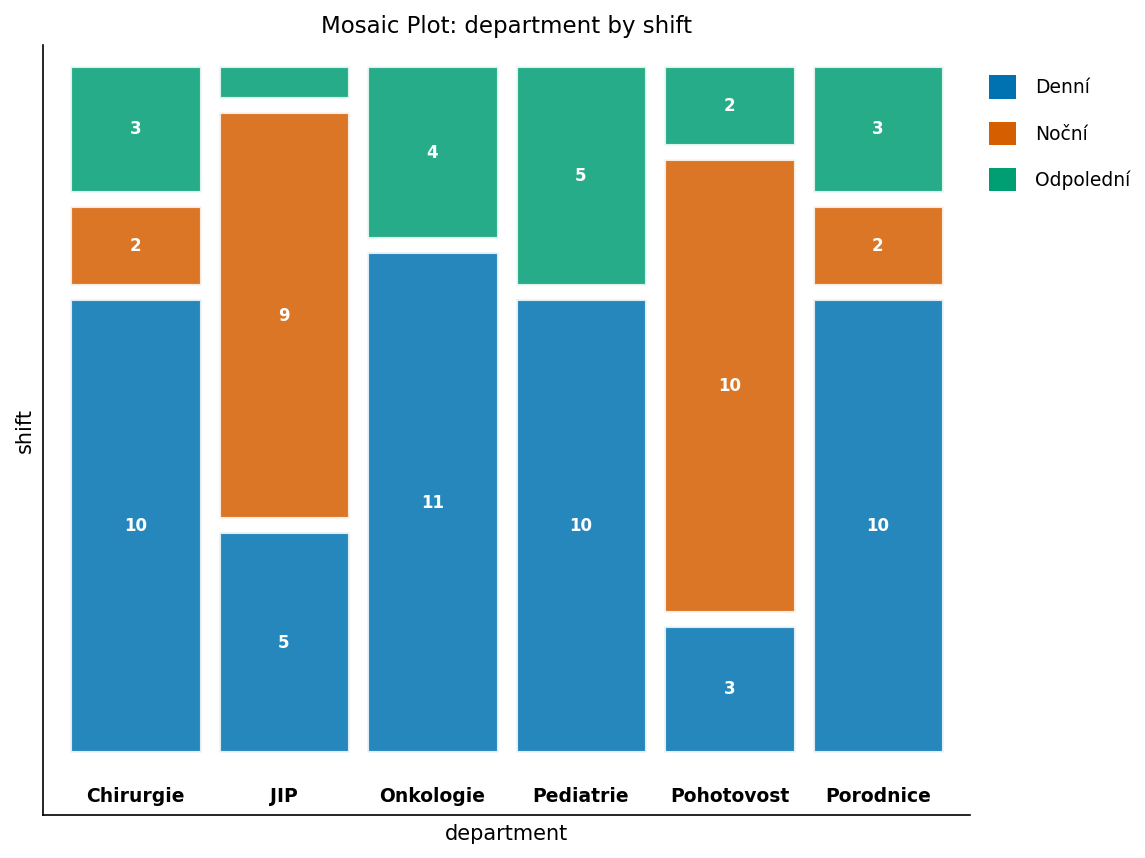

In [3]:
/* --------------------------------------------------------
   Základní tabulky: pracovní hodiny podle oddělení a
   rozložení denní / odpolední / noční směny podle oddělení.
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.staffing_log sum mean n maxdec=2;
    TŘÍDA department;
    PROMĚNNÁ hours_worked;
    NÁZEV "Pracovní hodiny podle oddělení";
SPUSTIT;

PROCEDURA ČETNOSTI data=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    NÁZEV "Rozložení směn podle oddělení";
SPUSTIT;
NÁZEV;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


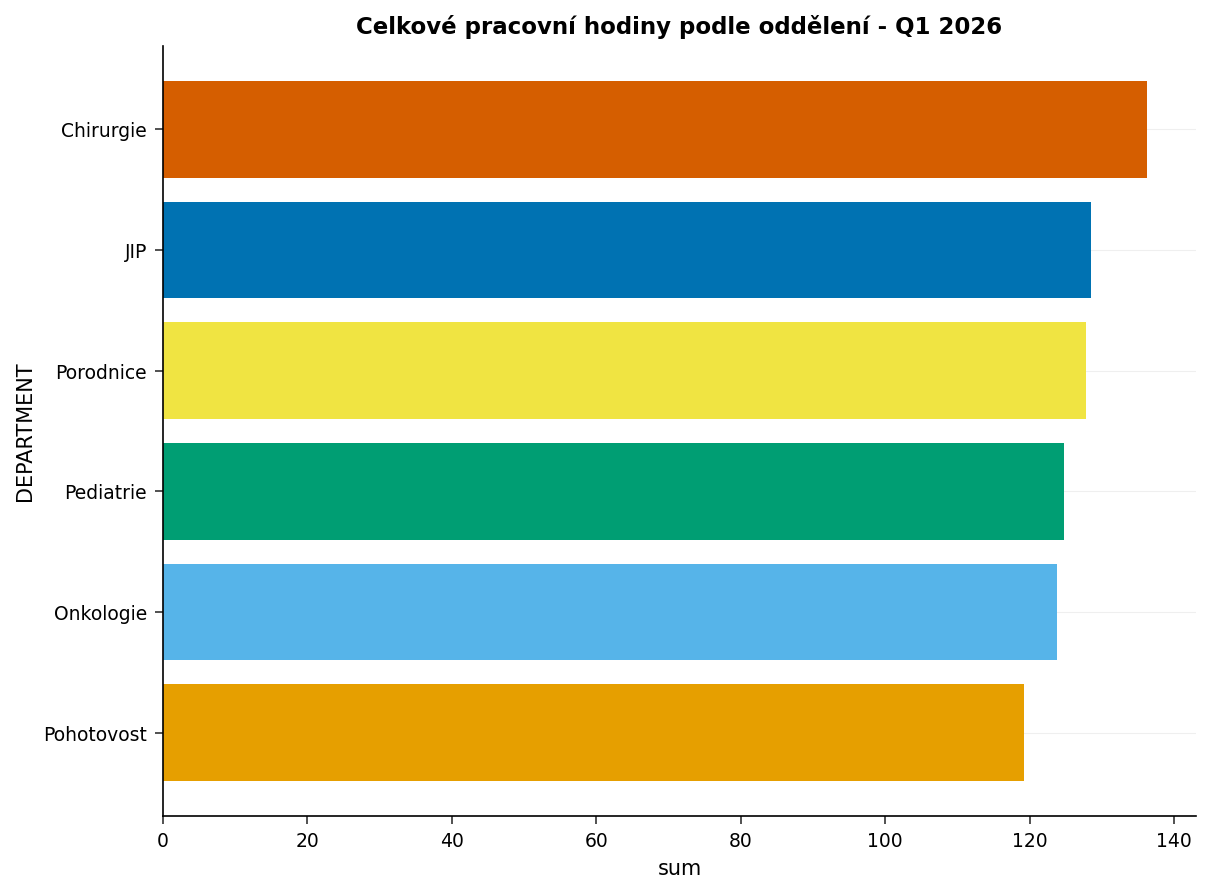

In [4]:
/* --------------------------------------------------------
   Přehledový HBAR: celkové pracovní hodiny podle oddělení.
   SUMVAR= sčítá hodiny; DESCENDING řadí sloupce sestupně.
   -------------------------------------------------------- */
PROCEDURA GCHART data=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      SESTUPNĚ;
    NÁZEV "Celkové pracovní hodiny podle oddělení - Q1 2026";
SPUSTIT;
QUIT;
NÁZEV;

### Rozdělení každého oddělení podle kategorie zdroje

`GROUP=` kreslí shluk sousedících vodorovných sloupců pro každé oddělení, jeden sloupec na kategorii zdroje. Protože je v platnosti `SUMVAR=hours_worked`, každý sloupec měří nasčítané odpracované hodiny, nikoli počet záznamů, takže graf ukazuje, jak se hodiny ošetřovatelství, lékařů, nelékařského personálu a podpory porovnávají *uvnitř* každého oddělení.

In [5]:
/* --------------------------------------------------------
   Příkazy PATTERN: sladěná paleta 4 barev,
   jeden vzor na podskupinu kategorie zdroje
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Ošetřovatelství — tmavě modrá */
pattern2 VALUE=solid color=cx28A745;   /* Lékaři — zelená             */
pattern3 VALUE=solid color=cxE8650A;   /* Nelékařský personál — jantarová */
pattern4 VALUE=solid color=cx6C757D;   /* Podpora — šedá              */

                                    Pracovní hodiny oddělení podle kategorie zdroje                                     


Zdroj: Systém řízení pracovních sil | Sledované období: leden-březen 2026



NOTE: Option TITLE changed to Pracovní hodiny oddělení podle kategorie zdroje.
NOTE: Option FOOTNOTE changed to Zdroj: Systém řízení pracovních sil | Sledované období: leden-březen 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


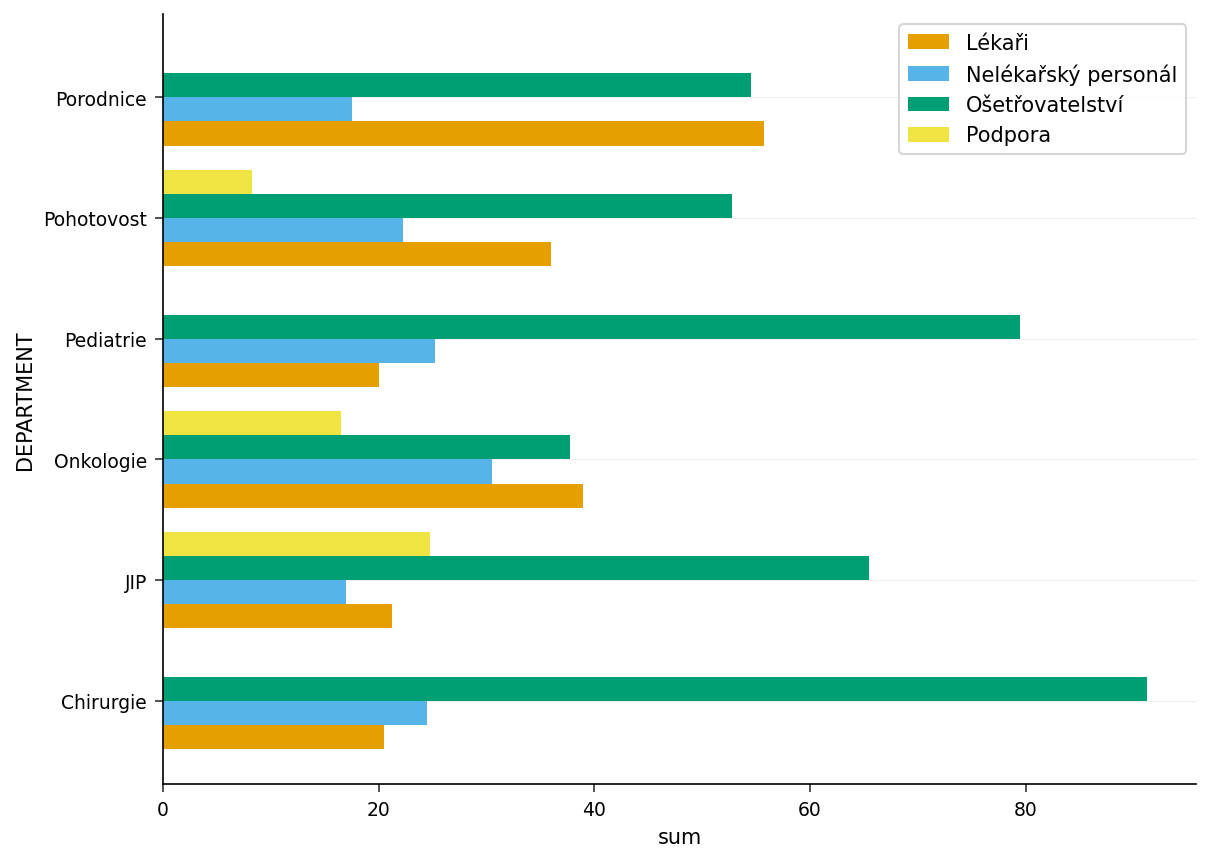

In [6]:
/* --------------------------------------------------------
   HBAR seskupený podle kategorie zdroje (GROUP=).
   Každé oddělení se stává shlukem sloupců -- jeden na
   kategorii zdroje -- měřeno v nasčítaných pracovních hodinách.
   -------------------------------------------------------- */
NÁZEV "Pracovní hodiny oddělení podle kategorie zdroje";
footnote JUSTIFY=LEFT
    "Zdroj: Systém řízení pracovních sil | Sledované období: leden-březen 2026";

PROCEDURA GCHART data=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
SPUSTIT;
QUIT;

NÁZEV; footnote;

                                          Pracovní hodiny oddělení podle směny                                          


Seskupené sloupce oddělují příspěvky denní / odpolední / noční směny v každém oddělení



NOTE: Option TITLE changed to Pracovní hodiny oddělení podle směny.
NOTE: Option FOOTNOTE changed to Seskupené sloupce oddělují příspěvky denní / odpolední / noční směny v každém oddělení.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


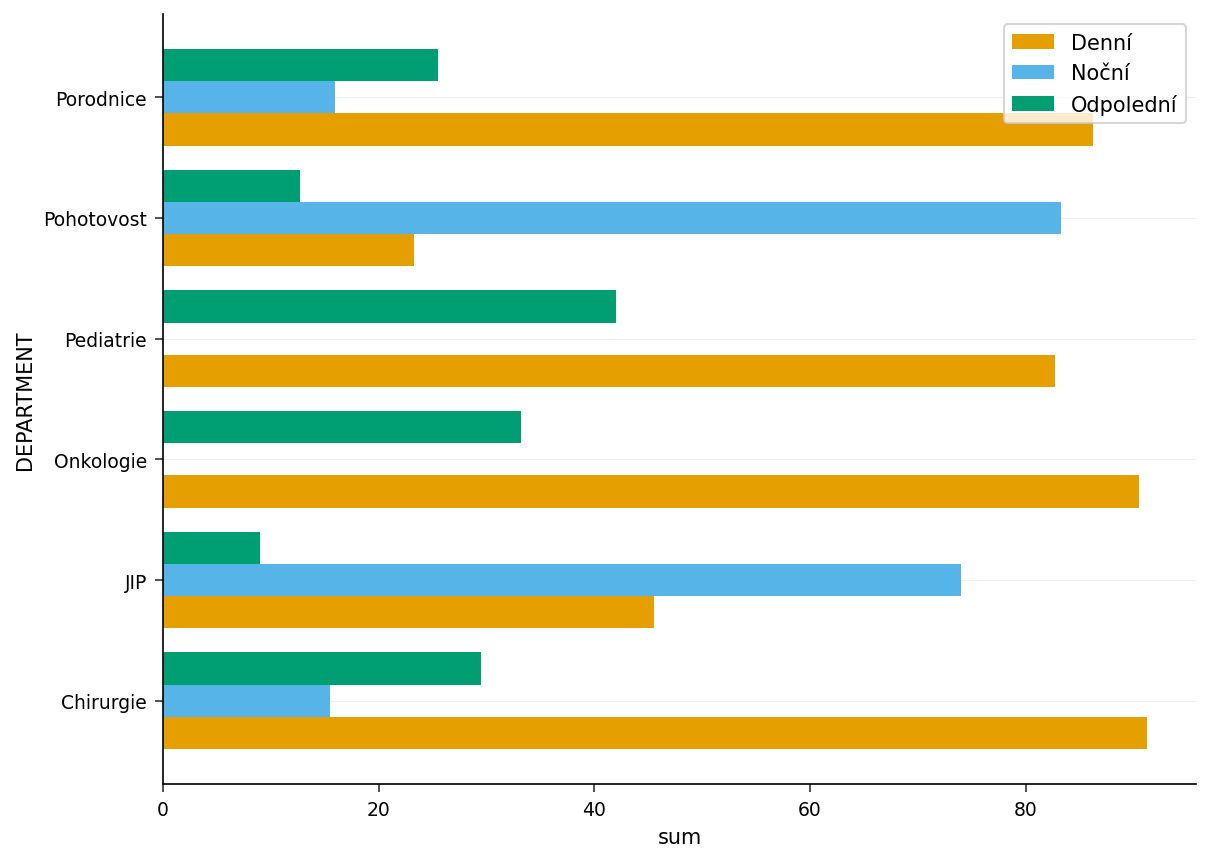

In [7]:
/* --------------------------------------------------------
   HBAR seskupený podle směny (GROUP=).
   Odděluje příspěvky denní / odpolední / noční směny
   v každém oddělení -- zvýrazňuje jednotky s nepřetržitým provozem.
   -------------------------------------------------------- */
NÁZEV "Pracovní hodiny oddělení podle směny";
footnote JUSTIFY=LEFT
    "Seskupené sloupce oddělují příspěvky denní / odpolední / noční směny v každém oddělení";

PROCEDURA GCHART data=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
SPUSTIT;
QUIT;

NÁZEV; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


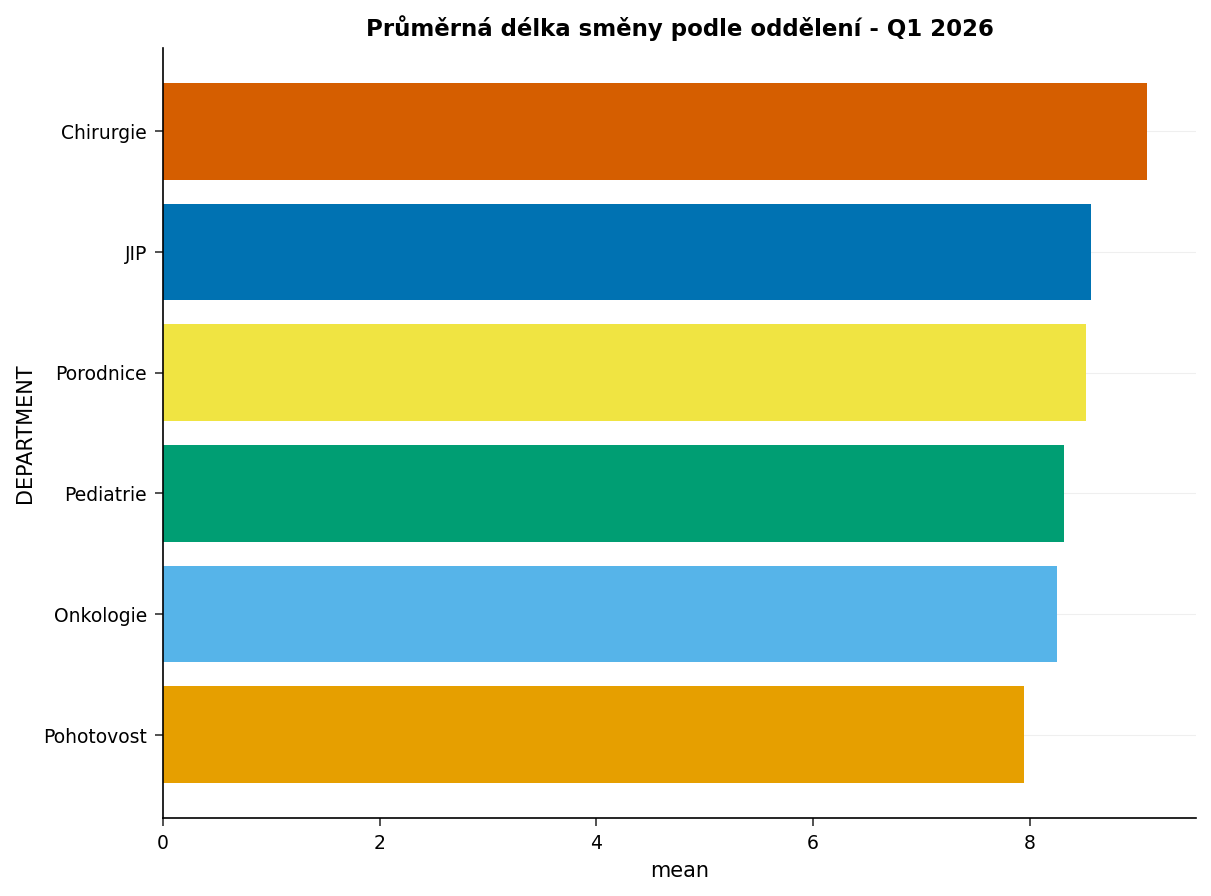

In [8]:
/* --------------------------------------------------------
   Průměrná délka směny podle oddělení (TYPE=MEAN).
   Ukazuje, zda oddělení má dlouhé směny, nebo více
   kratších, nezávisle na celkovém objemu.
   -------------------------------------------------------- */
PROCEDURA GCHART data=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      SESTUPNĚ;
    NÁZEV "Průměrná délka směny podle oddělení - Q1 2026";
SPUSTIT;
QUIT;
NÁZEV;

---

### Interpretace

Napříč 90 záznamy směn se celkové pracovní hodiny pohybují v úzkém pásmu od **119,25** (Pohotovost) do **136,25** (Chirurgie), protože každé oddělení má ve sledovaném období stejných 15 směn — takže pořadí odráží **délku směny**, nikoli počet směn. Chirurgie je na prvním místě jak v grafu celkových hodin, tak v grafu průměrné směny s **9,08 hodinami** na směnu, což odpovídá delším operačním případům a lékařsky náročnému obsazení, které tyto případy vyžadují. Pohotovost je na hodinách nejníže (průměr **7,95**), přestože patří mezi nejvytíženější jednotky, protože její práce probíhá v kratších směnách s vyšší obměnou.

HBAR seskupený podle směny a mozaikový panel vypovídají o provozně důležitém příběhu. **Pohotovost a JIP jsou nočně dominantní** — 10 z 15 a 9 z 15 směn připadá na noční směnu — zatímco **Onkologie a Pediatrie nemají žádné noční směny** a soustředí se na denní pokrytí (11 a 10 denních směn). Toto rozdělení odráží skutečné nemocniční obsazení: jednotky s nepřetržitou akutní péčí fungují nepřetržitě, zatímco onkologická infuzní léčba a všeobecná pediatrie jsou denní služby. Panel kategorie zdroje potvrzuje **mix vedený ošetřovatelstvím** v každém oddělení, přičemž hodiny lékařů a nelékařského personálu tvoří druhotné vrstvy.

Pro přezkum obsazení ve druhém čtvrtletí je koncentrace nočních směn na Pohotovosti a JIP položkou, kterou je třeba sledovat: právě zde se hromadí náklady na příplatky a řízení únavy a právě zde má jakákoli změna rotace největší dopad na rozpočet.

---

In [9]:
/* --------------------------------------------------------
   Export souhrnu za oddělení pro systém plánování
   pracovních sil.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Pohání <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>